In [1]:
pip install pyclustering

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyclustering.cluster import cluster_visualizer_multidim
from pyclustering.cluster.cure import cure
from pyclustering.utils import read_sample
from pyclustering.samples.definitions import SIMPLE_SAMPLES

# Load data (you can replace it with your own data)
sample = read_sample(SIMPLE_SAMPLES.SAMPLE_SIMPLE1)

# Number of clusters
amount_clusters = 4

# Maximum distance between two clusters to merge
compressing_factor = 0.5

# Maximum distance between two points within cluster
diameter_limit = 0.5

# Create CURE algorithm
cure_instance = cure(sample, amount_clusters, compressing_factor, diameter_limit)

# Run cluster analysis and obtain results
cure_instance.process()
clusters = cure_instance.get_clusters()
means = cure_instance.get_means()

# Visualize clustering results (if needed)
visualizer = cluster_visualizer_multidim()
visualizer.append_clusters(clusters, sample)
visualizer.append_cluster(means, marker='*', markersize=10)
visualizer.show()

# Print cluster centers and points indices
for cluster_index, center in enumerate(means):
    print(f"Cluster {cluster_index + 1} Center: {center}")
    print(f"Points Indices: {clusters[cluster_index]}")
    print()


TypeError: 'float' object cannot be interpreted as an integer

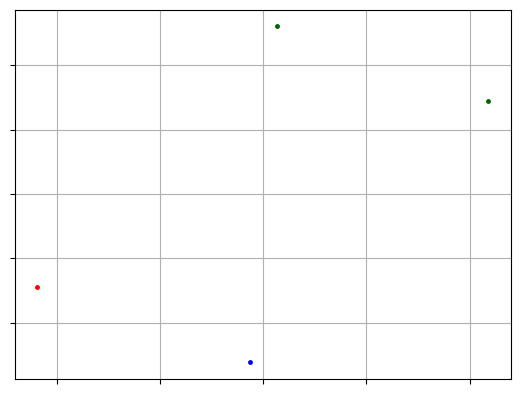

In [9]:
from pyclustering.cluster import cluster_visualizer;
from pyclustering.cluster.cure import cure;
from pyclustering.utils import read_sample;
from pyclustering.samples.definitions import FCPS_SAMPLES;
 
# Input data in following format [ [0.1, 0.5], [0.3, 0.1], ... ].
input_data = points_list#read_sample(FCPS_SAMPLES.SAMPLE_LSUN);
 
# Allocate three clusters.
cure_instance = cure(input_data, 3);
cure_instance.process();
clusters = cure_instance.get_clusters();
 
# Visualize allocated clusters.
visualizer = cluster_visualizer();
visualizer.append_clusters(clusters, input_data);
visualizer.show();

In [7]:
import numpy as np
from sklearn.manifold import MDS

# Sample adjacency matrix (replace it with your own adjacency matrix)
adjacency_matrix = np.array([
    [0, 1, 2, 3],
    [1, 0, 3, 2],
    [2, 3, 0, 1],
    [3, 2, 1, 0]
])

# Create MDS model
mds = MDS(n_components=2, dissimilarity='precomputed')

# Fit the model and transform the data to 2D coordinates
points_coordinates = mds.fit_transform(adjacency_matrix)

# List to store the coordinates of each point
points_list = []

# Store the coordinates in the list
for i, point in enumerate(points_coordinates):
    points_list.append((point[0], point[1]))

# Print the coordinates stored in the list
print("Point Coordinates:")
for i, point in enumerate(points_list):
    print(f"Point {i + 1}: ({point[0]}, {point[1]})")


Point Coordinates:
Point 1: (-1.092790991261677, -0.7227806086159807)
Point 2: (-0.0637042238211901, -1.3083426948917025)
Point 3: (0.06652447735172426, 1.3039827009965963)
Point 4: (1.0899707377311427, 0.7271406025110869)


In [8]:
points_list

[(-1.092790991261677, -0.7227806086159807),
 (-0.0637042238211901, -1.3083426948917025),
 (0.06652447735172426, 1.3039827009965963),
 (1.0899707377311427, 0.7271406025110869)]

In [ ]:
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import numpy as np
import matplotlib.pyplot as plt
from pyclustering.cluster.cure import cure
from pyclustering.utils import timedcall

# Load the PubMed dataset
dataset = Planetoid(root='/tmp/PubMed', name='PubMed', transform=NormalizeFeatures())
data = dataset[0]

# Extract features
features = data.x.numpy()

# Apply CURE clustering
# Number of clusters, number of representatives, and compression ratio can be tuned
number_of_clusters = 5
number_of_representatives = 5
compression = 0.2

# Initialize CURE algorithm
cure_instance = cure(features, number_of_clusters, number_of_representatives, compression)

# Run clustering
(ticks, result) = timedcall(cure_instance.process)

# Get clustering results
clusters = cure_instance.get_clusters()
representatives = cure_instance.get_representatives()

# Plot the results
plt.figure(figsize=(10, 7))
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
for i, cluster in enumerate(clusters):
    cluster_points = features[cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i % len(colors)], label=f'Cluster {i + 1}')
    
# Plot the representatives
for i, rep in enumerate(representatives):
    rep_points = np.array(rep)
    plt.scatter(rep_points[:, 0], rep_points[:, 1], c='k', marker='x', s=100)

plt.title('CURE Clustering on PubMed Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Processing...
Done!


In [1]:
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import numpy as np
import matplotlib.pyplot as plt
from pyclustering.cluster.cure import cure
from pyclustering.utils import timedcall

# Load the PubMed dataset
dataset = Planetoid(root='/tmp/PubMed', name='PubMed', transform=NormalizeFeatures())
data = dataset[0]

/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
features = data.x.numpy()

In [4]:
from sklearn.decomposition import PCA
import numpy as np

# Example data: word attributes (replace with your data)
#word_attributes = word_attributes

# Instantiate PCA object
pca = PCA(n_components=2)  # Reduce to 2 dimensions

# Fit and transform the data
word_attributes_reduced = pca.fit_transform(features)

# print("Original shape:", word_attributes.shape)
# print("Reduced shape:", word_attributes_reduced.shape)
# print("Reduced data:")
# print(word_attributes_reduced)


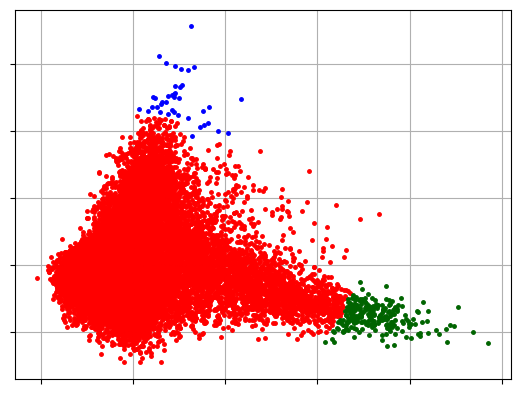

In [9]:
#CURE clustering
from pyclustering.cluster import cluster_visualizer;
from pyclustering.cluster.cure import cure;
from pyclustering.utils import read_sample;
from pyclustering.samples.definitions import FCPS_SAMPLES;
 
# Input data in following format [ [0.1, 0.5], [0.3, 0.1], ... ].
input_data = word_attributes_reduced#read_sample(FCPS_SAMPLES.SAMPLE_LSUN);
 
# Allocate three clusters.
cure_instance = cure(word_attributes_reduced, 3)
cure_instance.process();
clusters = cure_instance.get_clusters();
 
# Visualize allocated clusters.
visualizer = cluster_visualizer();
visualizer.append_clusters(clusters, input_data);
visualizer.show();